In [55]:
import numpy as np
import pandas as pd 

In [56]:
df = pd.read_csv('Attrition - Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [57]:
!pip install plotly
# 3d visualiziation library

In [58]:
import plotly.graph_objects as go 
import plotly.io as pio 
pio.templates.default='plotly_white'

In [59]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [60]:
df.empty

False

In [61]:
# Filter the data to show only yes values in attrition column

In [62]:
attr_df = df[df['Attrition']=='Yes']
attr_df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
14,28,Yes,Travel_Rarely,103,Research & Development,24,3,Life Sciences,1,19,...,2,80,0,6,4,3,4,2,0,3
21,36,Yes,Travel_Rarely,1218,Sales,9,4,Life Sciences,1,27,...,2,80,0,10,4,3,5,3,0,3
24,34,Yes,Travel_Rarely,699,Research & Development,6,1,Medical,1,31,...,3,80,0,8,2,3,4,2,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1438,23,Yes,Travel_Frequently,638,Sales,9,3,Marketing,1,2023,...,1,80,1,1,3,2,1,0,1,0
1442,29,Yes,Travel_Rarely,1092,Research & Development,1,4,Medical,1,2027,...,2,80,3,4,3,4,2,2,2,2
1444,56,Yes,Travel_Rarely,310,Research & Development,7,2,Technical Degree,1,2032,...,4,80,1,14,4,1,10,9,9,8
1452,50,Yes,Travel_Frequently,878,Sales,1,4,Life Sciences,1,2044,...,4,80,2,12,3,3,6,3,0,1


In [63]:
# Calculate the attrition by department 

In [64]:
attrition_by_dpt = attr_df.groupby(['Department']).size().reset_index(name='count')
attrition_by_dpt

,Department,count
0,Human Resources,12
1,Research & Development,133
2,Sales,92


In [65]:
# Create a donut chart
fig = go.Figure(data=[go.Pie(
    labels=attrition_by_dpt['Department'],
    values=attrition_by_dpt['count'], 
    hole=0.2,
    marker=dict(colors=['yellow', 'green']), 
    textposition='inside'
)])

# update the layout 
fig.update_layout(title='Attrition by Department')

# Show the chart  
fig.show()

In [66]:
# Calculate the attrition by Educationfield

In [67]:
attrition_by_eduf = attr_df.groupby(attr_df['EducationField']).size().reset_index(name='count')
attrition_by_eduf

,EducationField,count
0,Human Resources,7
1,Life Sciences,89
2,Marketing,35
3,Medical,63
4,Other,11
5,Technical Degree,32


In [68]:
# Create a donut chart
fig = go.Figure(data=[go.Pie(
    labels=attrition_by_eduf['EducationField'],
    values=attrition_by_eduf['count'], 
    hole=0.2,
    marker=dict(colors=['yellow', 'green']), 
    textposition='inside'
)])

# update the layout 
fig.update_layout(title='Attrition by Educationfield')

# Show the chart  
fig.show()

In [69]:
# kitne bande kitne saal me attrition kre

In [70]:
attr_df.groupby('YearsAtCompany').size().reset_index(name='Count')

,YearsAtCompany,Count
0,0,16
1,1,59
2,2,27
3,3,20
4,4,19
5,5,21
6,6,9
7,7,11
8,8,9
9,9,8


In [71]:
# We can see that most of the employees leave the organization after completing a year

In [72]:
attr_df.groupby(['YearsSinceLastPromotion']).size().reset_index(name='Count')

,YearsSinceLastPromotion,Count
0,0,110
1,1,49
2,2,27
3,3,9
4,4,5
5,5,2
6,6,6
7,7,16
8,9,4
9,10,1


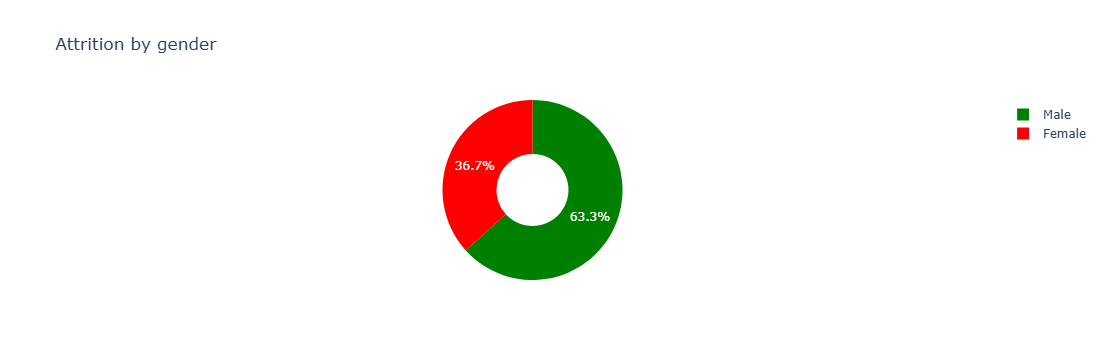

In [74]:
attrition_by_gender = attr_df.groupby(['Gender']).size().reset_index(name='count')
attrition_by_gender

# create a pie chart

fig = go.Figure(data=[go.Pie(
    labels = attrition_by_gender['Gender'], 
    values = attrition_by_gender['count'], 
    hole = 0.4, 
    marker = dict(colors=['red', 'green']), 
    textposition = 'inside'
)])

# update the layout  
fig.update_layout(title='Attrition by gender')

# show the chart  
fig.show()

In [75]:
import plotly.express as px 

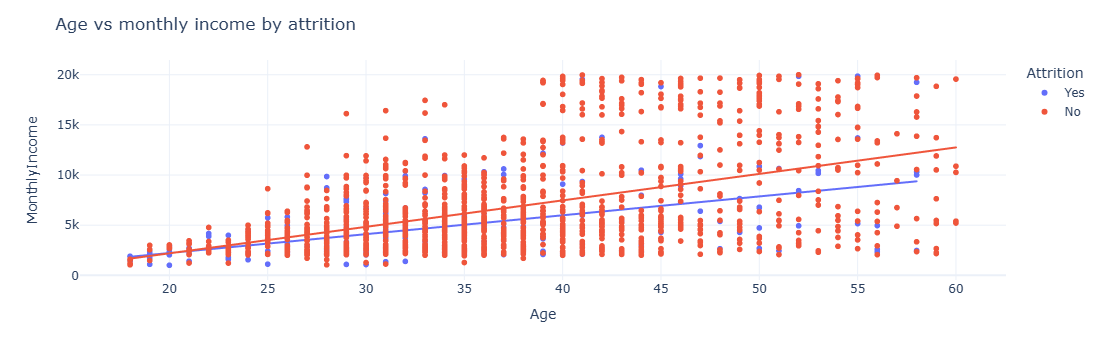

In [76]:
fig = px.scatter(df, x='Age', y='MonthlyIncome', color='Attrition', trendline='ols') 
fig.update_layout(title='Age vs monthly income by attrition')
fig.show()